**Nom :** [Double-cliquez ici pour entrer votre nom]

**Prénom :** [Double-cliquez ici pour entrer votre prénom]

# Mini-projet IA Chimie — Random Forest pour prédire la toxicité

## Objectif pédagogique

Ce notebook propose une approche **Machine Learning classique** avant ou en parallèle des réseaux de neurones.

L'idée principale est de montrer aux étudiants que :

> L'intelligence artificielle ne se limite pas aux réseaux de neurones.

Nous allons entraîner un modèle **Random Forest** pour prédire la toxicité de molécules à partir de leur structure chimique.

Le notebook permet de comparer :

- une approche avec **descripteurs moléculaires simples** ;
- une approche avec **empreintes de Morgan** ;
- un modèle **Random Forest** ;
- éventuellement un petit **MLP** pour comparaison.

## Compétences travaillées

À la fin du mini-projet, l'étudiant doit pouvoir :

1. comprendre comment une molécule est transformée en données numériques ;
2. entraîner un modèle de classification ;
3. évaluer un modèle avec une matrice de confusion et un score ROC-AUC ;
4. interpréter les limites d'un modèle en toxicologie ;
5. comprendre pourquoi un modèle simple peut parfois être très performant.

## 1. Installation des bibliothèques

Ce notebook utilise :

- `RDKit` pour manipuler les molécules ;
- `scikit-learn` pour entraîner le modèle Random Forest ;
- `DeepChem` pour charger le jeu de données ClinTox.

Sur Google Colab, décommentez la cellule suivante si les bibliothèques ne sont pas installées.

In [128]:
# Si nécessaire dans Google Colab, décommenter les lignes suivantes :
# !pip install rdkit-pypi deepchem scikit-learn matplotlib pandas numpy

## 2. Importation des bibliothèques

In [129]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from rdkit import Chem
from rdkit.Chem import Descriptors, Crippen, rdMolDescriptors, Draw
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator

from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    RocCurveDisplay,
    classification_report
)

RANDOM_STATE = 42

## 3. Chargement du jeu de données ClinTox

ClinTox contient des molécules associées à des informations de toxicité clinique.

Pour garder le notebook simple, nous utilisons ici la tâche `CT_TOX`, qui indique si une molécule est associée à une toxicité.

> Remarque : en toxicologie réelle, les données sont souvent déséquilibrées, bruitées et incomplètes. C'est justement un bon contexte pour développer l'esprit critique.

In [130]:
try:
    import deepchem as dc
    tasks, datasets, transformers = dc.molnet.load_clintox(featurizer='Raw', splitter='random')
    train_dataset, valid_dataset, test_dataset = datasets
    
    def dc_to_dataframe(dataset):
        smiles = dataset.ids
        y = dataset.y
        return pd.DataFrame({
            'smiles': smiles,
            'CT_TOX': y[:, list(tasks).index('CT_TOX')]
        })
    
    df = pd.concat([
        dc_to_dataframe(train_dataset),
        dc_to_dataframe(valid_dataset),
        dc_to_dataframe(test_dataset)
    ], ignore_index=True)
    
    print('Dataset ClinTox chargé avec DeepChem.')

except Exception as e:
    print('DeepChem indisponible ou erreur de téléchargement.')
    print('Le notebook utilise une petite base de démonstration intégrée.')
    
    data = [
        ('CCO', 0),                         # ethanol
        ('CC(=O)C', 0),                     # acetone
        ('CC(=O)O', 0),                     # acetic acid
        ('CC(C)CC1=CC=C(C=C1)C(C)C(=O)O', 0), # ibuprofen
        ('CC(=O)NC1=CC=C(C=C1)O', 0),      # paracetamol
        ('Cn1cnc2n(C)c(=O)n(C)c(=O)c12', 0), # caffeine
        ('c1ccccc1', 1),                    # benzene
        ('ClC(Cl)Cl', 1),                   # chloroform
        ('C=CCCl', 1),                      # allyl chloride
        ('C=CC(=O)O', 1),                   # acrylic acid
        ('ClC=CCl', 1),                     # dichloroethylene
        ('C1=CC=C(C=C1)[N+](=O)[O-]', 1),  # nitrobenzene
        ('CCCl', 1),                        # chloroethane
        ('C1=CC=C2C=CC=CC2=C1', 1),        # naphthalene
        ('CO', 1),                          # methanol
        ('CCCCCCCCO', 0),                   # octanol, demo label
        ('CC(C)O', 0),                      # isopropanol
        ('CCN(CC)CC', 0),                   # triethylamine, demo label
        ('C(CCl)Cl', 1),                    # dichloroethane
        ('BrCBr', 1),                       # dibromomethane
    ]
    df = pd.DataFrame(data, columns=['smiles', 'CT_TOX'])

df = df.dropna().reset_index(drop=True)
df.head(), df.shape

Dataset ClinTox chargé avec DeepChem.


(                                              smiles  CT_TOX
 0  CN(CC(CO)O)C(=O)c1c(c(c(c(c1I)NC(=O)COC)I)C(=O...     0.0
 1  CCCCc1c(c2ccccc2o1)C(=O)c3cc(c(c(c3)I)OCC[NH+]...     0.0
 2  CCCCCCCCCCCCCCCC[N+](C)(C)CCN(Cc1ccc(cc1)OC)c2...     0.0
 3                        c1cc(ccc1C(=O)NCC(=O)[O-])N     0.0
 4  CC(C)c1cccc(c1NC(=O)C[NH+](CC(=O)[O-])CC(=O)[O...     0.0,
 (1480, 2))

## 4. Nettoyage et visualisation de quelques molécules

Nous vérifions que les chaînes SMILES sont correctement lues par RDKit.

Nombre de molécules valides : 1480
CT_TOX
0.0    1368
1.0     112
Name: count, dtype: int64


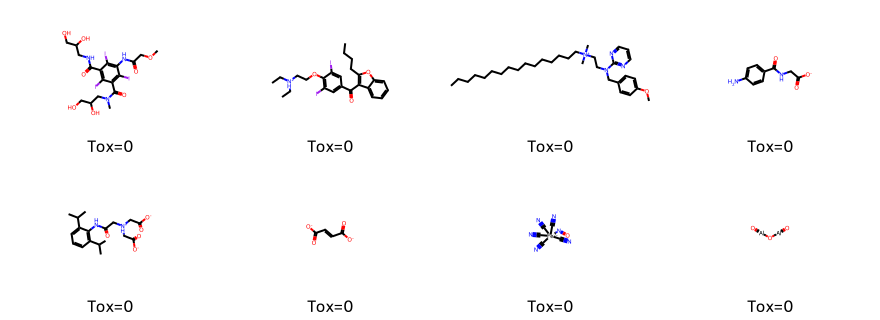

In [131]:
def smiles_to_mol(smiles):
    try:
        return Chem.MolFromSmiles(smiles)
    except Exception:
        return None

df['mol'] = df['smiles'].apply(smiles_to_mol)
df = df[df['mol'].notna()].reset_index(drop=True)

print('Nombre de molécules valides :', len(df))
print(df['CT_TOX'].value_counts())

mols = list(df['mol'].head(8))
legends = [f'Tox={int(v)}' for v in df['CT_TOX'].head(8)]
Draw.MolsToGridImage(mols, molsPerRow=4, subImgSize=(220, 160), legends=legends)

## 5. Calcul de descripteurs moléculaires simples

Nous calculons quelques propriétés classiques :

- masse molaire ;
- LogP ;
- TPSA ;
- nombre de donneurs de liaison H ;
- nombre d'accepteurs de liaison H ;
- nombre d'atomes lourds ;
- nombre de cycles ;
- nombre d'halogènes.

Ces variables sont compréhensibles par un chimiste, ce qui facilite l'interprétation.

In [132]:
def count_halogens(mol):
    halogens = {'F', 'Cl', 'Br', 'I'}
    return sum(1 for atom in mol.GetAtoms() if atom.GetSymbol() in halogens)

def molecular_descriptors(mol):
    return {
        'MolWt': Descriptors.MolWt(mol),
        'LogP': Crippen.MolLogP(mol),
        'TPSA': rdMolDescriptors.CalcTPSA(mol),
        'HBD': rdMolDescriptors.CalcNumHBD(mol),
        'HBA': rdMolDescriptors.CalcNumHBA(mol),
        'HeavyAtoms': mol.GetNumHeavyAtoms(),
        'Rings': rdMolDescriptors.CalcNumRings(mol),
        'Halogens': count_halogens(mol),
    }

desc_df = pd.DataFrame([molecular_descriptors(mol) for mol in df['mol']])
df_desc = pd.concat([df[['smiles', 'CT_TOX']], desc_df], axis=1)
df_desc.head()

,smiles,CT_TOX,MolWt,LogP,TPSA,HBD,HBA,HeavyAtoms,Rings,Halogens
0,CN(CC(CO)O)C(=O)c1c(c(c(c(c1I)NC(=O)COC)I)C(=O...,0.0,791.115,-0.4065,168.66,6,8,32,1,3
1,CCCCc1c(c2ccccc2o1)C(=O)c3cc(c(c(c3)I)OCC[NH+]...,0.0,646.327,5.5191,43.88,1,3,31,3,2
2,CCCCCCCCCCCCCCCC[N+](C)(C)CCN(Cc1ccc(cc1)OC)c2...,0.0,511.819,8.0495,38.25,0,4,37,2,0
3,c1cc(ccc1C(=O)NCC(=O)[O-])N,0.0,193.182,-1.2515,95.25,2,4,14,1,0
4,CC(C)c1cccc(c1NC(=O)C[NH+](CC(=O)[O-])CC(=O)[O...,0.0,349.407,-1.7434,113.80,2,5,25,1,0


## 6. Premier modèle : Random Forest avec descripteurs simples

Avant de lancer le calcul, prenons un instant pour comprendre comment "réfléchit" cet algorithme.

### 🌳 Qu'est-ce qu'un Arbre de Décision ?
Imaginez un chimiste qui trie des molécules en posant des questions binaires (Oui/Non) :
1. *Le LogP est-il supérieur à 3 ?* (Si oui, la molécule est très lipophile, elle passe dans la branche de droite).
2. *La masse molaire (MolWt) est-elle inférieure à 500 g/mol ?*
3. *A-t-elle plus de 2 halogènes ?*

Au bout de ces questions, l'arbre rend un verdict final : **Toxique** ou **Non Toxique**.
*Le problème d'un seul arbre*, c'est qu'il a tendance à apprendre le jeu de données par cœur (surapprentissage) et manque de nuance.

### 🌲 Qu'est-ce qu'une "Forêt Aléatoire" (Random Forest) ?
Pour corriger cela, on va créer une véritable **forêt** contenant des centaines d'arbres (ici, nous en mettrons 300 avec `n_estimators=300`). 
Lorsqu'on présentera une nouvelle molécule inconnue, **chaque arbre de la forêt va voter**. La décision finale sera prise à la majorité. C'est le principe de la *sagesse de la foule*.

**Pourquoi "Aléatoire" ?**
Pour éviter que les 300 arbres ne posent tous les mêmes questions dans le même ordre, on introduit de l'aléatoire :
- Chaque arbre n'est entraîné que sur une **fraction des molécules** tirée au sort.
- À chaque question, l'arbre n'a le droit de choisir que parmi un **petit groupe de descripteurs** tirés au sort (ex: il n'a le droit d'utiliser que le TPSA et le nombre de cycles, mais pas le LogP).

Cette diversité garantit que la forêt dans son ensemble sera très robuste !


In [133]:
X = desc_df.values
y = df['CT_TOX'].astype(int).values

# Avec ClinTox, le dataset est assez grand pour séparer train/test.
# Avec la petite base de secours, le test sera seulement démonstratif.
stratify = y if len(np.unique(y)) == 2 and min(np.bincount(y)) > 1 else None
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=stratify
)

rf_desc = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=RANDOM_STATE,
    class_weight='balanced'
)
rf_desc.fit(X_train, y_train)

y_pred = rf_desc.predict(X_test)
y_proba = rf_desc.predict_proba(X_test)[:, 1]

print('Accuracy :', round(accuracy_score(y_test, y_pred), 3))

if len(np.unique(y_test)) == 2:
    print('ROC-AUC :', round(roc_auc_score(y_test, y_proba), 3))
else:
    print('ROC-AUC non calculable : une seule classe dans le test.')

print('Rapport de classification :')
print(classification_report(y_test, y_pred, zero_division=0))

Accuracy : 0.908
ROC-AUC : 0.663
Rapport de classification :
              precision    recall  f1-score   support

           0       0.92      0.98      0.95       342
           1       0.00      0.00      0.00        28

    accuracy                           0.91       370
   macro avg       0.46      0.49      0.48       370
weighted avg       0.85      0.91      0.88       370



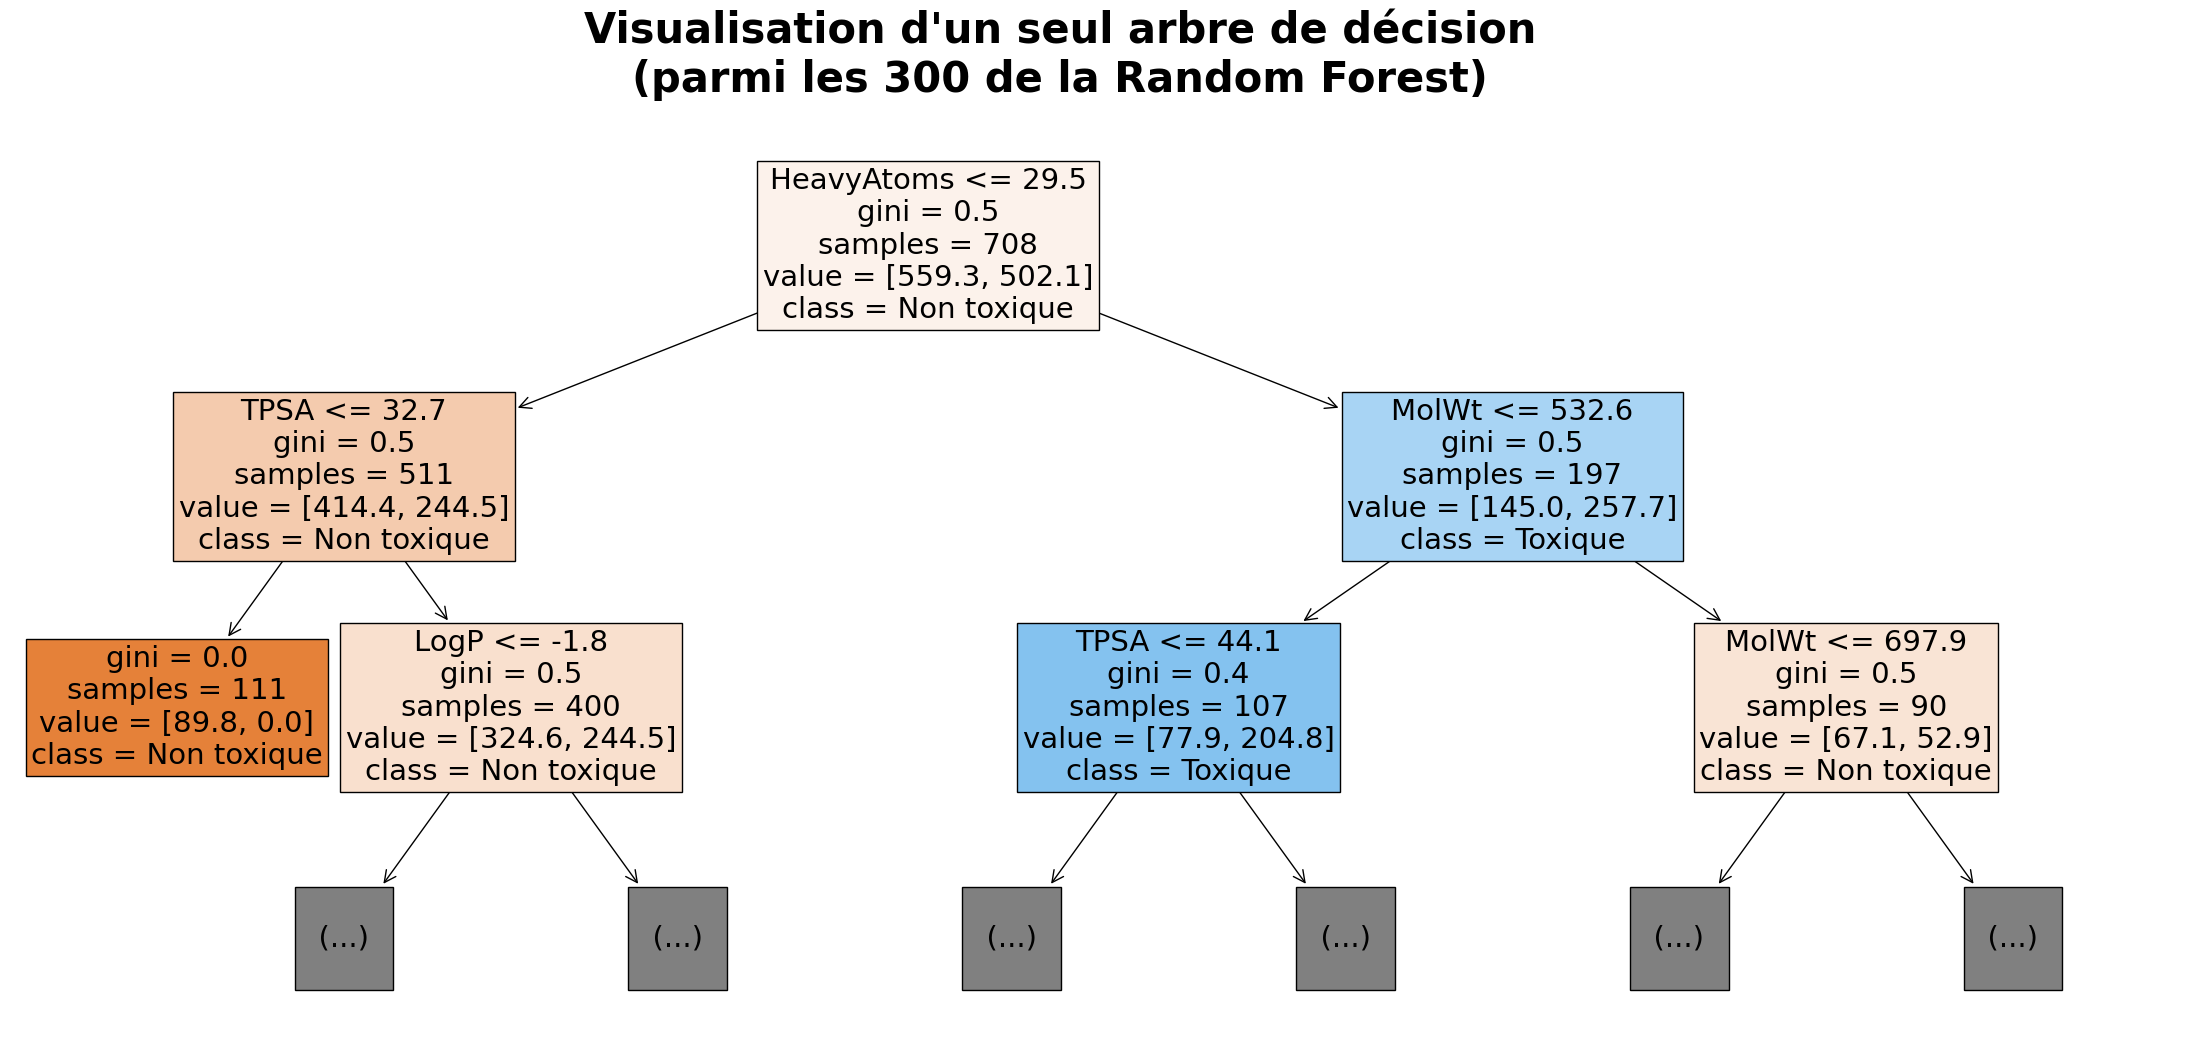

In [134]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Pour illustrer, nous allons dessiner un SEUL arbre parmi les 300 de notre forêt.
# Nous limitons la profondeur à 2 (max_depth=2) pour que l'image reste lisible.
fig = plt.figure(figsize=(28, 12))  # <-- Largeur augmentée à 28
plot_tree(rf_desc.estimators_[0], 
          feature_names=desc_df.columns,
          class_names=['Non toxique', 'Toxique'],
          filled=True, 
          max_depth=2, 
          fontsize=21,
          precision=1)              # <-- ASTUCE : Réduit la taille du texte dans les carrés
fig.suptitle("Visualisation d'un seul arbre de décision\n(parmi les 300 de la Random Forest)", fontsize=30, fontweight="bold", y=0.98)
plt.show()


L'image ci-dessus est générée automatiquement à partir de **vos données**. Vous pouvez voir exactement quelles questions chimiques (ex: LogP <= X) l'arbre pose pour séparer les molécules toxiques des non-toxiques !

**Comment lire les cases de l'arbre ?**
- **samples** : Le nombre de molécules qui sont arrivées jusqu'à cette étape.
- **value = [X, Y]** : Parmi ces molécules, il y a X "Non toxiques" et Y "Toxiques". L'arbre cherche à les séparer.
- **gini** : (Du nom du statisticien Corrado Gini, ce n'est pas un sigle !) C'est un score mathématique d'**impureté**. Un gini de 0.5 signifie que le groupe est totalement mélangé (50% toxique, 50% sain). Un gini de 0.0 signifie que l'arbre a parfaitement isolé un groupe pur !
- **class** : La décision finale majoritaire dans cette case.


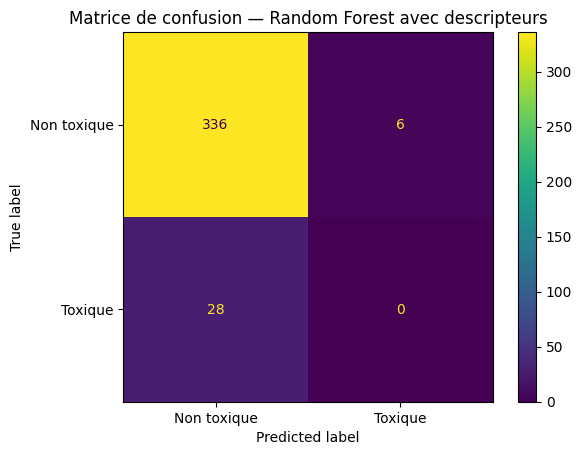

In [135]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non toxique', 'Toxique'])
disp.plot()
plt.title('Matrice de confusion — Random Forest avec descripteurs')
plt.show()

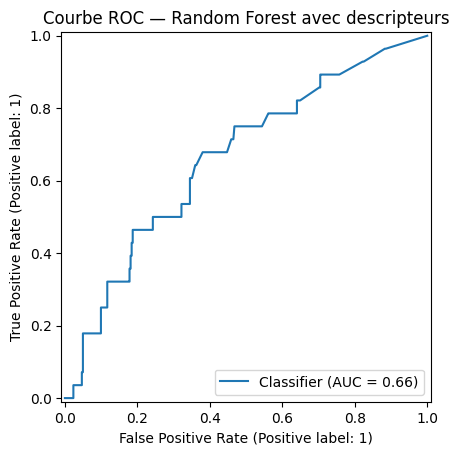

In [136]:
if len(np.unique(y_test)) == 2:
    RocCurveDisplay.from_predictions(y_test, y_proba)
    plt.title('Courbe ROC — Random Forest avec descripteurs')
    plt.show()

### Analyse des performances du premier modèle

**Question 1 : Au vu de la matrice de confusion ci-dessus, pourquoi la simple mesure de *l'accuracy* peut-elle être trompeuse en toxicologie ? (Indice : pensez à la gravité d'un Faux Négatif par rapport à un Faux Positif).**

> <span style="color: #3498db;">*Double-cliquez ici pour rédiger votre réponse...*</span>

## 7. Importance des variables

La Random Forest permet d'observer quelles propriétés ont le plus contribué à la décision.

Attention : importance statistique ne signifie pas causalité chimique.

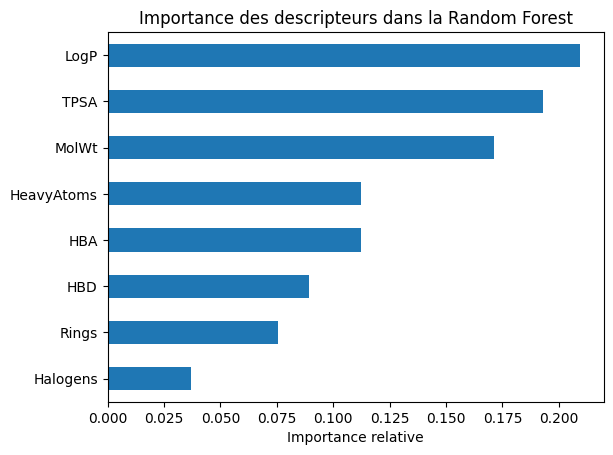

LogP          0.209384
TPSA          0.192852
MolWt         0.171294
HeavyAtoms    0.112407
HBA           0.112329
HBD           0.089299
Rings         0.075366
Halogens      0.037071
dtype: float64

In [137]:
importances = pd.Series(rf_desc.feature_importances_, index=desc_df.columns)
importances = importances.sort_values(ascending=True)

importances.plot(kind='barh')
plt.xlabel('Importance relative')
plt.title('Importance des descripteurs dans la Random Forest')
plt.show()

importances.sort_values(ascending=False)

## 8. Deuxième modèle : Random Forest avec empreintes de Morgan

Les descripteurs simples sont interprétables, mais ils résument fortement la molécule.

Les empreintes de Morgan décrivent la présence ou l'absence de fragments moléculaires locaux.

Elles sont souvent utilisées en chimio-informatique pour les modèles QSAR.

**Question 2 : Quelle différence fondamentale y a-t-il entre les descripteurs moléculaires simples (comme le LogP ou la Masse molaire) et les empreintes de Morgan (Fingerprints) en termes d'interprétabilité pour un chimiste ?**

> <span style="color: #3498db;">*Double-cliquez ici pour rédiger votre réponse...*</span>

In [138]:
morgan_generator = GetMorganGenerator(radius=2, fpSize=2048)

def morgan_fingerprint(mol):
    fp = morgan_generator.GetFingerprint(mol)
    arr = np.zeros((2048,), dtype=int)
    # Convert explicit bit vector to numpy array
    from rdkit.DataStructs import ConvertToNumpyArray
    ConvertToNumpyArray(fp, arr)
    return arr

X_fp = np.array([morgan_fingerprint(mol) for mol in df['mol']])
y = df['CT_TOX'].astype(int).values

X_train_fp, X_test_fp, y_train_fp, y_test_fp = train_test_split(
    X_fp, y, test_size=0.25, random_state=RANDOM_STATE, stratify=stratify
)

rf_fp = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=RANDOM_STATE,
    class_weight='balanced'
)
rf_fp.fit(X_train_fp, y_train_fp)

y_pred_fp = rf_fp.predict(X_test_fp)
y_proba_fp = rf_fp.predict_proba(X_test_fp)[:, 1]

print('Accuracy :', round(accuracy_score(y_test_fp, y_pred_fp), 3))

if len(np.unique(y_test_fp)) == 2:
    print('ROC-AUC :', round(roc_auc_score(y_test_fp, y_proba_fp), 3))
else:
    print('ROC-AUC non calculable : une seule classe dans le test.')

print('Rapport de classification :')
print(classification_report(y_test_fp, y_pred_fp, zero_division=0))

Accuracy : 0.908
ROC-AUC : 0.76
Rapport de classification :
              precision    recall  f1-score   support

           0       0.93      0.98      0.95       342
           1       0.12      0.04      0.06        28

    accuracy                           0.91       370
   macro avg       0.53      0.51      0.50       370
weighted avg       0.86      0.91      0.88       370



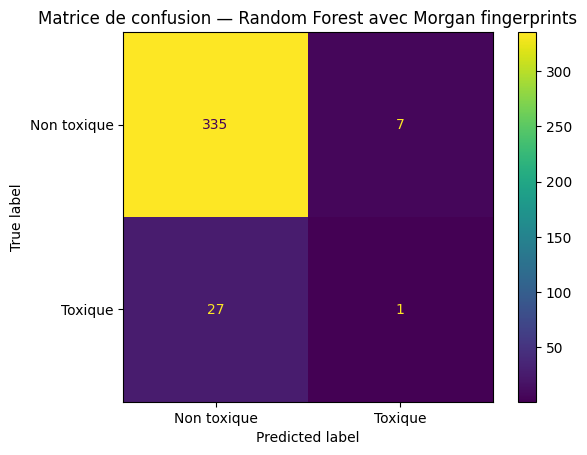

In [139]:
cm = confusion_matrix(y_test_fp, y_pred_fp)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non toxique', 'Toxique'])
disp.plot()
plt.title('Matrice de confusion — Random Forest avec Morgan fingerprints')
plt.show()

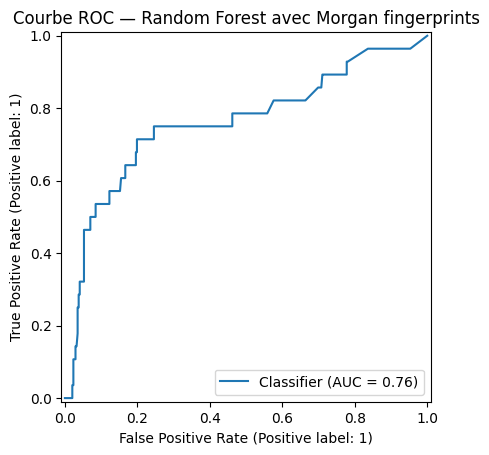

In [140]:
if len(np.unique(y_test_fp)) == 2:
    RocCurveDisplay.from_predictions(y_test_fp, y_proba_fp)
    plt.title('Courbe ROC — Random Forest avec Morgan fingerprints')
    plt.show()

## 9. Comparaison optionnelle avec un petit MLP

Cette partie permet de discuter une idée importante :

> Un réseau de neurones n'est pas automatiquement meilleur qu'un modèle classique.

Sur un dataset limité, une Random Forest peut être plus robuste et plus simple à utiliser.

In [141]:
mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    max_iter=400,
    random_state=RANDOM_STATE,
    early_stopping=True
)

mlp.fit(X_train_fp, y_train_fp)
y_pred_mlp = mlp.predict(X_test_fp)
y_proba_mlp = mlp.predict_proba(X_test_fp)[:, 1]

print('Accuracy MLP :', round(accuracy_score(y_test_fp, y_pred_mlp), 3))

if len(np.unique(y_test_fp)) == 2:
    print('ROC-AUC MLP :', round(roc_auc_score(y_test_fp, y_proba_mlp), 3))
else:
    print('ROC-AUC non calculable.')

Accuracy MLP : 0.916
ROC-AUC MLP : 0.717


In [142]:
results = []

if len(np.unique(y_test)) == 2:
    results.append({
        'Modèle': 'Random Forest + descripteurs',
        'Accuracy': accuracy_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_proba)
    })

if len(np.unique(y_test_fp)) == 2:
    results.append({
        'Modèle': 'Random Forest + Morgan',
        'Accuracy': accuracy_score(y_test_fp, y_pred_fp),
        'ROC-AUC': roc_auc_score(y_test_fp, y_proba_fp)
    })
    results.append({
        'Modèle': 'MLP + Morgan',
        'Accuracy': accuracy_score(y_test_fp, y_pred_mlp),
        'ROC-AUC': roc_auc_score(y_test_fp, y_proba_mlp)
    })

results_df = pd.DataFrame(results)
results_df

,Modèle,Accuracy,ROC-AUC
0,Random Forest + descripteurs,0.908108,0.662751
1,Random Forest + Morgan,0.908108,0.760338
2,MLP + Morgan,0.916216,0.716949


### Comparaison des modèles

**Question 3 : Le modèle utilisant les empreintes de Morgan est-il systématiquement bien meilleur que celui utilisant les descripteurs simples ? Justifiez au vu de vos résultats affichés dans le tableau ci-dessus.**

> <span style="color: #3498db;">*Double-cliquez ici pour rédiger votre réponse...*</span>

## 10. Prédire la toxicité d'une molécule choisie par l'étudiant

Modifiez le SMILES ci-dessous pour tester une molécule de votre choix.

Exemples :

- caféine : `Cn1cnc2n(C)c(=O)n(C)c(=O)c12`
- aspirine : `CC(=O)OC1=CC=CC=C1C(=O)O`
- paracétamol : `CC(=O)NC1=CC=C(C=C1)O`
- benzène : `c1ccccc1`

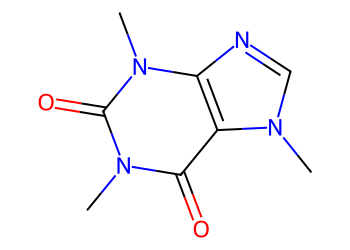

In [143]:
smiles_etudiant = 'Cn1cnc2n(C)c(=O)n(C)c(=O)c12'  # caféine
mol_etudiant = Chem.MolFromSmiles(smiles_etudiant)

if mol_etudiant is None:
    raise ValueError('SMILES non valide')

Draw.MolToImage(mol_etudiant, size=(350, 250))

In [144]:
desc_etudiant = pd.DataFrame([molecular_descriptors(mol_etudiant)])
fp_etudiant = np.array([morgan_fingerprint(mol_etudiant)])

proba_desc = rf_desc.predict_proba(desc_etudiant.values)[0, 1]
proba_fp = rf_fp.predict_proba(fp_etudiant)[0, 1]

print('Molécule étudiée :', smiles_etudiant)
print('Descripteurs calculés :')
display(desc_etudiant)

print('Probabilité de toxicité estimée :')
print('Random Forest avec descripteurs :', round(proba_desc, 3))
print('Random Forest avec Morgan fingerprints :', round(proba_fp, 3))

Molécule étudiée : Cn1cnc2n(C)c(=O)n(C)c(=O)c12
Descripteurs calculés :


,MolWt,LogP,TPSA,HBD,HBA,HeavyAtoms,Rings,Halogens
0,194.194,-1.0293,61.82,0,3,14,2,0


Probabilité de toxicité estimée :
Random Forest avec descripteurs : 0.109
Random Forest avec Morgan fingerprints : 0.099


### Analyse de la prédiction

**Question 4 : Le modèle prédit une "probabilité" (par exemple 0.70) pour votre molécule. Peut-on conclure avec une certitude absolue que la molécule est toxique pour l'Homme ? Que signifie réellement ce chiffre pour le modèle Random Forest ?**

> <span style="color: #3498db;">*Double-cliquez ici pour rédiger votre réponse...*</span>

## 11. Questions de synthèse

**Question 5 : Quelles limites majeures voyez-vous dans ce modèle QSAR appliqué à la toxicologie (par exemple concernant la dose, le mécanisme d'action, le déséquilibre des données, etc.) ?**

> <span style="color: #3498db;">*Double-cliquez ici pour rédiger votre réponse...*</span>

**Question 6 : Nos modèles actuels (Random Forest, Naive Bayes) "résument" la molécule en un tableau de nombres (propriétés globales ou fingerprints locaux). En quoi les Réseaux de Neurones de Graphes (GNN) pourraient-ils offrir une approche fondamentalement différente ?**

> <span style="color: #3498db;">*Double-cliquez ici pour rédiger votre réponse...*</span>

## 12. Conclusion pédagogique

Ce mini-projet complète les notebooks sur les réseaux de neurones.

Il montre qu'en chimie :

- les modèles classiques restent très utiles ;
- Random Forest est robuste, simple et souvent efficace ;
- la représentation moléculaire est aussi importante que l'algorithme ;
- les GNN deviennent intéressants lorsque l'on veut exploiter plus directement la structure moléculaire.

Message clé :

> Le meilleur modèle n'est pas toujours le plus complexe. Le bon choix dépend des données, du problème chimique et du niveau d'interprétation attendu.

# 13. Rendu du travail

Puisque vous avez répondu directement dans les cellules bleues de ce document, **vous n'avez pas de compte rendu séparé à rendre**.

Assurez-vous simplement :
1. D'avoir bien indiqué vos noms et prénoms au tout début du notebook.
2. D'avoir répondu à toutes les questions dans les cellules bleues.
3. D'enregistrer ce fichier `.ipynb`.

Déposez ensuite directement ce notebook complété sur la plateforme de votre cours.